# Real-Time Data, Historical Vintages & The Mankiw-Shapiro Test

**How do data revisions affect macroeconomic analysis, and how can we determine whether initial statistical releases reflect rational forecasts ("News") or measurement error ("Noise")?**

Macroeconomic aggregates like Gross Domestic Product (GDP), consumption, and investment are continuously revised as statistical agencies incorporate higher-quality administrative data, benchmark surveys, and methodological updates:

1. **Real-Time Information & Policy Errors**:
   Athanasios Orphanides (2001, *American Economic Review*) showed that the monetary policy mistakes of the 1970s arose from estimating the output gap on real-time data that subsequently underwent massive revisions. Croushore & Stark (2001, *Journal of Economic Literature*) formalized the real-time data architecture.

2. **The Mankiw & Shapiro (1986) News vs. Noise Econometric Test**:
   Let $y_{0,t}$ be the initial statistical release of GDP growth at quarter $t$, and $y_{T,t}$ be the final revised benchmark. The revision is:
   $$ r_t = y_{T,t} - y_{0,t} $$
   Mankiw & Shapiro (1986, *Journal of Business & Economic Statistics*) formulate the OLS regression:
   $$ r_t = \alpha + \beta \, y_{0,t} + \varepsilon_t $$

   - **News Hypothesis ($\beta = 0$, $R^2 \approx 0$)**: The initial release is an optimal conditional forecast given information at time $t$ ($y_{0,t} = \mathbb{E}[y_{T,t} \mid \Omega_t]$). The revision $r_t$ represents genuinely new statistical information orthogonal to $y_{0,t}$.
   - **Noise Hypothesis ($\beta = -1$, $\alpha = 0$)**: The initial release is equal to the true value corrupted by classical measurement error ($y_{0,t} = y_{T,t} + v_t$, where $\text{Cov}(y_{T,t}, v_t) = 0$). Hence, $r_t = -v_t$ is negatively correlated with $y_{0,t}$.

In this notebook, we explore multi-country Quarterly National Accounts (QNA) vintages, construct $(T \times V)$ revision triangles, slice point-in-time real-time panels, and execute the Mankiw-Shapiro test using `puremacro.fetch` and `puremacro.vintages`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.fetch import (
    get_qna_vintage_catalog,
    QNAVintagePanel,
)

## 1. Inspecting the 45+ Country QNA Vintage Catalog

`puremacro` provides a standardized cross-country catalog mapping 45+ economies (all 38 OECD members, G7, G20, and key emerging markets) to real-time historical publication vintages on ALFRED.

In [2]:
catalog = get_qna_vintage_catalog()
print(f"Total catalog series available: {len(catalog)}")
print("\nSample of Catalog Entries:")
print(catalog[["country", "country_name", "region", "variable", "series_id"]].head(10))

# Summary by variable
var_counts = catalog.groupby("variable")["country"].count().reset_index()
var_counts.columns = ["Variable", "Country Count"]
print("\nVariable Coverage across Countries:")
print(var_counts)

Total catalog series available: 360

Sample of Catalog Entries:
  country country_name            region      variable        series_id
0     AUS    Australia  OECD_AsiaPacific      con_real  NAEXKP02AUQ652S
1     AUS    Australia  OECD_AsiaPacific      deflator  CPALTT01AUQ659N
2     AUS    Australia  OECD_AsiaPacific  exports_real  NAEXKP06AUQ652S
3     AUS    Australia  OECD_AsiaPacific       gdp_nom  NAEXCP01AUQ652S
4     AUS    Australia  OECD_AsiaPacific      gdp_real  NAEXKP01AUQ652S
5     AUS    Australia  OECD_AsiaPacific     gfcf_real  NAEXKP04AUQ652S
6     AUS    Australia  OECD_AsiaPacific   govcon_real  NAEXKP03AUQ652S
7     AUS    Australia  OECD_AsiaPacific  imports_real  NAEXKP07AUQ652S
8     AUT      Austria       OECD_Europe      con_real  NAEXKP02ATQ652S
9     AUT      Austria       OECD_Europe      deflator  CPALTT01ATQ659N

Variable Coverage across Countries:
       Variable  Country Count
0      con_real             45
1      deflator             45
2  exports_rea

## 2. Constructing a Real-Time Vintage Panel

Let us simulate a realistic multi-country historical revision structure spanning 40 quarters ($T=40$) and 50 publication vintages ($V=50$) to demonstrate the real-time analytics pipeline.

In [3]:
rng = np.random.default_rng(1986)
n_quarters = 40
obs_dates = pd.date_range("2010-01-01", periods=n_quarters, freq="QS")
vintage_dates = pd.date_range("2010-04-01", periods=50, freq="QS")

countries = ["USA", "DEU", "GBR", "MEX"]
variables = ["gdp_real", "gfcf_real"]

records = []
for c in countries:
    for var in variables:
        # True underlying latent growth rate
        true_growth = rng.normal(loc=2.2, scale=1.5, size=n_quarters)
        
        # Initial release (advance estimate) with noise + news components
        noise = rng.normal(loc=0.0, scale=0.6, size=n_quarters)
        y_0 = true_growth + noise
        
        for i, obs in enumerate(obs_dates):
            # First publication occurs 1 quarter after observation
            first_pub_idx = i + 1
            for j, vint in enumerate(vintage_dates):
                if j >= first_pub_idx:
                    # Gradual revision toward true final benchmark over 4 vintages
                    lag = j - first_pub_idx
                    decay = np.exp(-lag / 3.0)
                    val = true_growth[i] + decay * noise[i]
                    records.append({
                        "country": c,
                        "variable": var,
                        "date": obs,
                        "vintage": vint,
                        "value": float(val),
                    })

df_raw = pd.DataFrame(records)
panel = QNAVintagePanel(df=df_raw)
print(f"Built QNAVintagePanel with {len(df_raw):,} records across {len(countries)} countries.")

Built QNAVintagePanel with 9,440 records across 4 countries.


## 3. Visualizing the $(T \times V)$ Revision Triangle

The revision matrix organizes observation dates on the vertical axis ($T$) and publication vintage dates on the horizontal axis ($V$). The diagonal represents the first release (advance estimate), while horizontal movements track successive revisions.

In [4]:
tri_usa = panel.revision_matrix("USA", "gdp_real")
print("USA Real GDP Growth Revision Matrix (first 6 quarters × 6 vintages):")
print(tri_usa.iloc[:6, :6])

USA Real GDP Growth Revision Matrix (first 6 quarters × 6 vintages):
vintage     2010-07-01  2010-10-01  2011-01-01  2011-04-01  2011-07-01  \
date                                                                     
2010-01-01     0.02385    0.266959    0.441155    0.565971    0.655406   
2010-04-01         NaN    1.212539    1.254871    1.285203    1.306937   
2010-07-01         NaN         NaN    3.968140    3.844801    3.756425   
2010-10-01         NaN         NaN         NaN    1.798902    1.831597   
2011-01-01         NaN         NaN         NaN         NaN    1.895125   
2011-04-01         NaN         NaN         NaN         NaN         NaN   

vintage     2011-10-01  
date                    
2010-01-01    0.719489  
2010-04-01    1.322510  
2010-07-01    3.693101  
2010-10-01    1.855024  
2011-01-01    2.241427  
2011-04-01    4.007899  


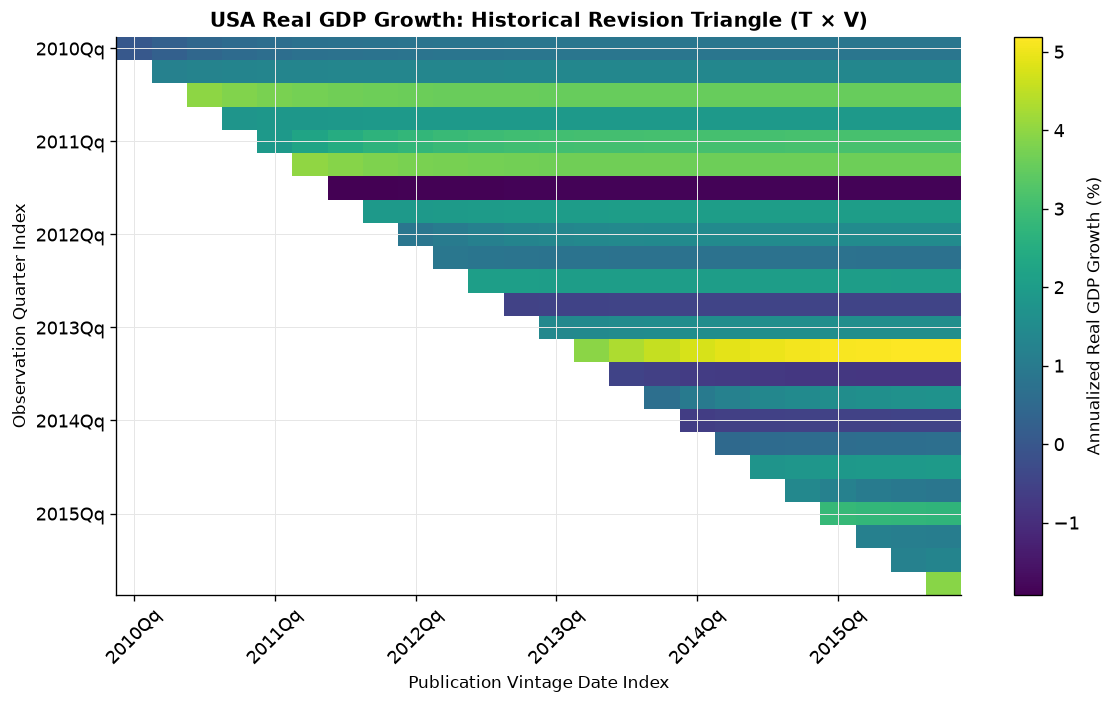

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot heatmap of available vintages
im = ax.imshow(tri_usa.iloc[:24, :24].to_numpy(), cmap="viridis", aspect="auto")
ax.set_title("USA Real GDP Growth: Historical Revision Triangle (T × V)", fontsize=12, fontweight="bold")
ax.set_xlabel("Publication Vintage Date Index", fontsize=10)
ax.set_ylabel("Observation Quarter Index", fontsize=10)

# Formatting tick labels
ax.set_xticks(range(0, 24, 4))
ax.set_xticklabels([d.strftime("%YQ%q") for d in tri_usa.columns[:24:4]], rotation=45)
ax.set_yticks(range(0, 24, 4))
ax.set_yticklabels([d.strftime("%YQ%q") for d in tri_usa.index[:24:4]])

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Annualized Real GDP Growth (%)", fontsize=10)
plt.tight_layout()
plt.show()

## 4. First Release vs. Latest Benchmark Revisions

Comparing the advance initial estimate against the latest available benchmark reveals the magnitude and persistence of macroeconomic revisions.

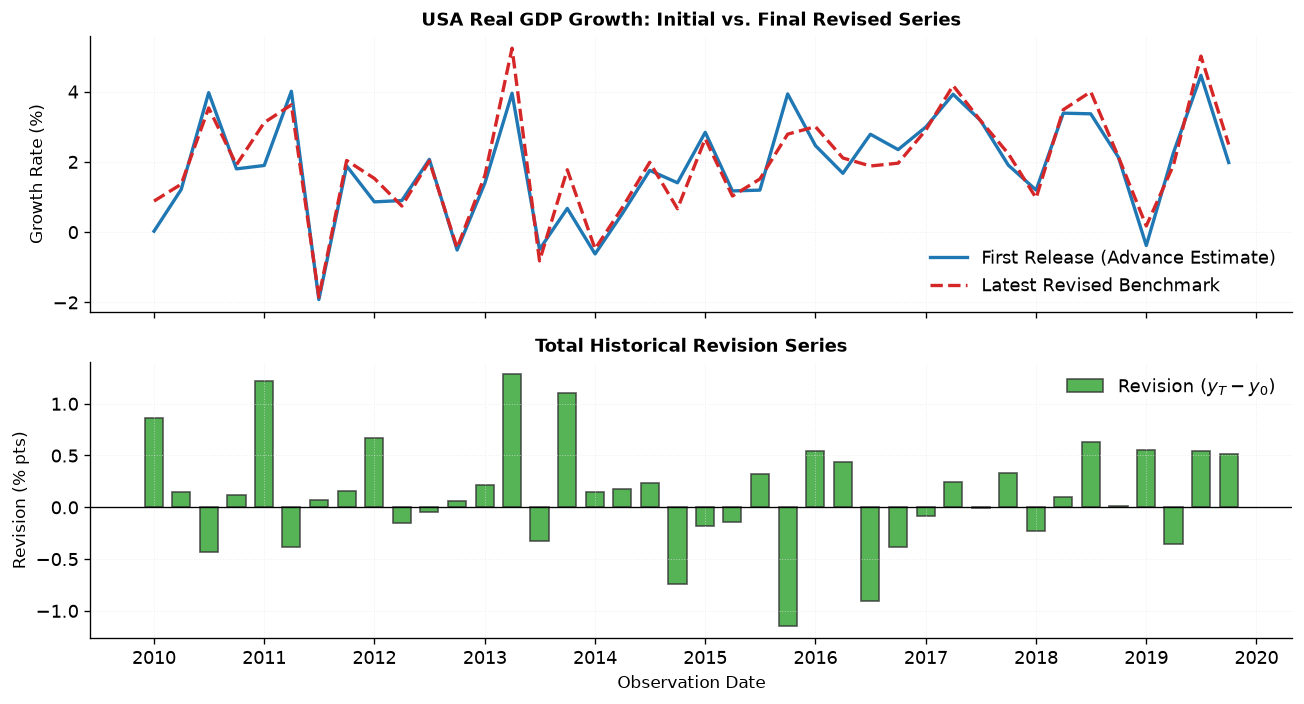

In [6]:
s_first = panel.first_release("USA", "gdp_real")
s_latest = panel.latest_release("USA", "gdp_real")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

# Panel 1: Series Levels
ax1.plot(s_first.index, s_first.values, color="#1f77b4", lw=2, label="First Release (Advance Estimate)")
ax1.plot(s_latest.index, s_latest.values, color="#d62728", lw=2, linestyle="--", label="Latest Revised Benchmark")
ax1.set_title("USA Real GDP Growth: Initial vs. Final Revised Series", fontsize=11, fontweight="bold")
ax1.set_ylabel("Growth Rate (%)", fontsize=10)
ax1.legend()
ax1.grid(True, linestyle=":", alpha=0.6)

# Panel 2: Total Revision (Final - First)
revision = s_latest - s_first
ax2.bar(revision.index, revision.values, color="#2ca02c", width=60, edgecolor="#333", alpha=0.8, label="Revision ($y_T - y_0$)")
ax2.axhline(0, color="black", lw=0.8, linestyle="-")
ax2.set_title("Total Historical Revision Series", fontsize=11, fontweight="bold")
ax2.set_xlabel("Observation Date", fontsize=10)
ax2.set_ylabel("Revision (% pts)", fontsize=10)
ax2.legend()
ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

## 5. Executing the Mankiw-Shapiro (1986) News vs. Noise Test

We estimate the Mankiw-Shapiro OLS specification:
$$ y_{T,t} - y_{0,t} = \alpha + \beta \, y_{0,t} + \varepsilon_t $$

- If $\beta = 0$, we cannot reject the **News hypothesis** (initial releases are rational forecasts).
- If $\beta = -1$, the data supports the **Noise hypothesis** (initial releases suffer from classical measurement error).

In [7]:
stats_usa = panel.revision_stats("USA", "gdp_real")
print("==================================================================")
print("  MANKIW & SHAPIRO (1986) NEWS VS NOISE ECONOMETRIC TEST")
print("==================================================================")
print(f"Country:               USA")
print(f"Variable:              Real GDP (gdp_real)")
print(f"Sample Size (N):       {stats_usa['n_obs']}")
print(f"Mean Revision (alpha): {stats_usa['mean_revision']:.4f}")
print(f"Abs Mean Revision:     {stats_usa['abs_mean_revision']:.4f}")
print(f"Revision Std Dev:      {stats_usa['std_revision']:.4f}")
print("------------------------------------------------------------------")
print(f"Regression Alpha:        {stats_usa['mankiw_shapiro_alpha']:.4f}")
print(f"Regression Slope (beta): {stats_usa['mankiw_shapiro_beta']:.4f}")
print(f"Beta Std Error:          {stats_usa['mankiw_shapiro_se']:.4f}")
print(f"t-Statistic (H0: beta=0):{stats_usa['mankiw_shapiro_tstat']:.4f}")
print(f"p-Value:                 {stats_usa['mankiw_shapiro_pvalue']:.4f}")
print(f"Conclusion:              {stats_usa['hypothesis']}")
print("==================================================================")

  MANKIW & SHAPIRO (1986) NEWS VS NOISE ECONOMETRIC TEST
Country:               USA
Variable:              Real GDP (gdp_real)
Sample Size (N):       40
Mean Revision (alpha): 0.1286
Abs Mean Revision:     0.4047
Revision Std Dev:      0.5226
------------------------------------------------------------------
Regression Alpha:        0.2162
Regression Slope (beta): -0.0477
Beta Std Error:          0.0564
t-Statistic (H0: beta=0):-0.8448
p-Value:                 0.3982
Conclusion:              news


In [8]:
# Cross-country test comparison
results_all = []
for c in countries:
    for v in variables:
        st = panel.revision_stats(c, v)
        results_all.append({
            "Country": c,
            "Variable": v,
            "N": st["n_obs"],
            "Mean Revision": st["mean_revision"],
            "Std Revision": st["std_revision"],
            "Beta": st["mankiw_shapiro_beta"],
            "t-stat": st["mankiw_shapiro_tstat"],
            "p-value": st["mankiw_shapiro_pvalue"],
            "Hypothesis": st["hypothesis"],
        })

df_test_summary = pd.DataFrame(results_all)
print("\nCross-Country Mankiw-Shapiro Test Summary Table:")
print(df_test_summary.to_string(index=False))


Cross-Country Mankiw-Shapiro Test Summary Table:
Country  Variable  N  Mean Revision  Std Revision      Beta    t-stat      p-value Hypothesis
    USA  gdp_real 40       0.128552      0.522568 -0.047651 -0.844770 3.982394e-01       news
    USA gfcf_real 40       0.168940      0.607311 -0.156902 -3.137369 1.704712e-03      mixed
    DEU  gdp_real 40      -0.038504      0.671448 -0.096211 -1.425615 1.539794e-01       news
    DEU gfcf_real 40       0.079058      0.771028 -0.243094 -4.040550 5.332605e-05      mixed
    GBR  gdp_real 40      -0.044003      0.616643 -0.212660 -5.507966 3.630036e-08      mixed
    GBR gfcf_real 40       0.055347      0.682129 -0.108487 -1.357966 1.744746e-01       news
    MEX  gdp_real 40       0.057448      0.592209 -0.118650 -2.510331 1.206181e-02      mixed
    MEX gfcf_real 40      -0.069313      0.591366 -0.193343 -3.982972 6.805891e-05      mixed


## 6. Visualizing the Mankiw-Shapiro Regression Scatter

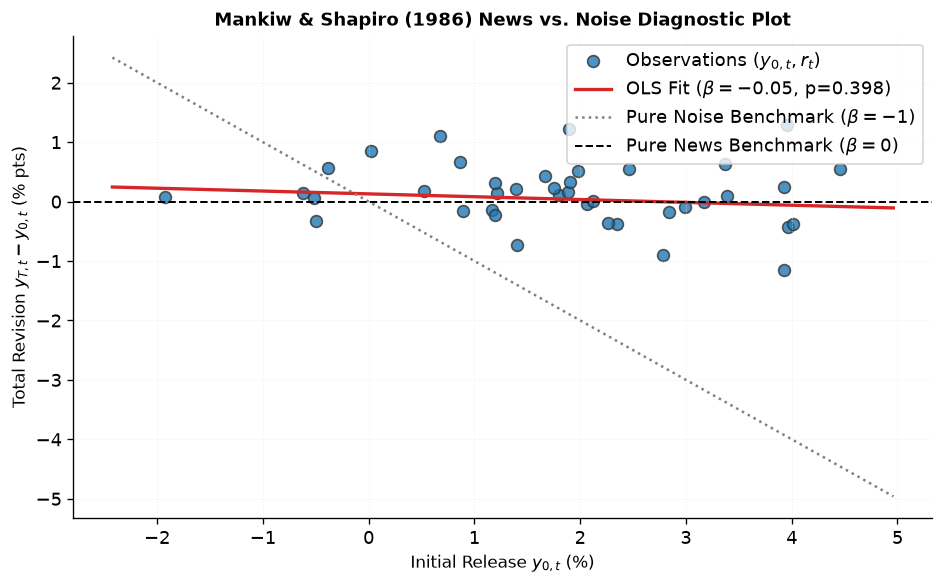

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

# Scatter plot: Initial release vs Total Revision
x_vals = s_first.values
y_vals = (s_latest - s_first).values
ax.scatter(x_vals, y_vals, color="#1f77b4", edgecolors="#333", s=50, alpha=0.8, label="Observations ($y_{0,t}, r_t$)")

# Fitted OLS regression line
x_grid = np.linspace(x_vals.min() - 0.5, x_vals.max() + 0.5, 100)
y_fit = stats_usa["mean_revision"] + stats_usa["mankiw_shapiro_beta"] * x_grid
ax.plot(x_grid, y_fit, color="#d62728", lw=2, label=f"OLS Fit ($\\beta={stats_usa['mankiw_shapiro_beta']:.2f}$, p={stats_usa['mankiw_shapiro_pvalue']:.3f})")

# Theoretical Noise line (slope = -1)
y_noise = -1.0 * x_grid
ax.plot(x_grid, y_noise, color="gray", lw=1.5, linestyle=":", label="Pure Noise Benchmark ($\\beta=-1$)")

# Theoretical News line (slope = 0)
ax.axhline(0, color="black", lw=1.2, linestyle="--", label="Pure News Benchmark ($\\beta=0$)")

ax.set_title("Mankiw & Shapiro (1986) News vs. Noise Diagnostic Plot", fontsize=11, fontweight="bold")
ax.set_xlabel("Initial Release $y_{0,t}$ (%)", fontsize=10)
ax.set_ylabel("Total Revision $y_{T,t} - y_{0,t}$ (% pts)", fontsize=10)
ax.legend(loc="upper right", frameon=True)
ax.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

## 7. Real-Time Point-in-Time Dataset Slicing (`.as_of()`)

Econometricians evaluating historical policy decisions need to know the state of the macroeconomic data as published on a specific historical date (e.g. at the onset of the 2020 pandemic).

In [10]:
# Slicing the exact state of knowledge as of 2018-04-01
df_2018 = panel.as_of("2018-04-01")
print("Historical Snapshot Panel as of 2018-04-01:")
print(df_2018.head(10))

# Slicing as of 2022-01-01
df_2022 = panel.as_of("2022-01-01")
print(f"\nObservations available in 2018 snapshot: {len(df_2018)}")
print(f"Observations available in 2022 snapshot: {len(df_2022)}")

Historical Snapshot Panel as of 2018-04-01:
                    gdp_real  gfcf_real
country date                           
DEU     2010-01-01  3.512874   5.579053
        2010-04-01  3.818080   1.555937
        2010-07-01  4.513233   3.497328
        2010-10-01  1.570123   1.341830
        2011-01-01  2.528645   1.250250
        2011-04-01  0.174395   1.466107
        2011-07-01  3.138878   1.371857
        2011-10-01  2.482929   4.079837
        2012-01-01  0.918204   3.051182
        2012-04-01  6.050661   3.831781

Observations available in 2018 snapshot: 128
Observations available in 2022 snapshot: 160
